# Notebook 02: Baseline de Composición de Outfits

**Propósito:** medir qué se combina con qué en Garments2Look: longitud de outfit, cobertura de catálogo, co-ocurrencia de categorías y set de evaluación FITB para el recomendador. El 01 mide si el probador genera bien; este mide si las combinaciones tienen estructura. Autocontenido: carga sus propios datos, no depende de la memoria del 01.

**Objetos que define:** `outfits`, `outfits_mvp`, `garments_per_outfit`, `prom`, `combo_cnt`, `fitb_set`

## 0b. Setup MLflow Tracking (igual que el 01)

Mismo tracking remoto que el 01 (ngrok + MLflow). Se instala `mlflow==3.16.1` igual que en el baseline.


In [37]:
# Instalar MLflow para tracking remoto (necesario en Colab antes del import)
%pip install -q "mlflow==3.16.1"


In [38]:
import mlflow
REMOTE_URI = "https://humorous-trusting-domelike.ngrok-free.dev"
try:
    mlflow.set_tracking_uri(REMOTE_URI)
    mlflow.set_experiment("01-baseline-garments2look")
    print(f"[OK] MLflow remoto: {REMOTE_URI}")
except Exception as e:
    print(f"[WARN] MLflow remoto no levantado ({e})")
    print(f"   Levanta local: uv run python backend/scripts/mlflow_ngrok.py")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(10)


[OK] MLflow remoto: https://humorous-trusting-domelike.ngrok-free.dev


In [39]:
# ---- Carga autocontenida (no depende de la memoria del 01) ----
# Replica la normalización del 01 y adapta dict->lista con cruce de catálogo.
from huggingface_hub import hf_hub_download
from collections import Counter
import json
import numpy as np

REPO_ID = "ArtmeScienceLab/Garments2Look"
REPO_TYPE = "dataset"
OUTFIT_METADATA_FILES = ["mytheresa_outfit_v1.0_2512.json", "polyvore_outfit_v1.0_2512.json"]
IMAGE_METADATA_FILES = ["mytheresa_image_v1.0_2512.json", "polyvore_image_v1.0_2512.json"]

def _descargar_json(fname):
    path = hf_hub_download(repo_id=REPO_ID, filename=fname, repo_type=REPO_TYPE)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def _partir_categoria(type_str):
    if not type_str:
        return "sin_catalogo", "sin_catalogo"
    partes = type_str.split("::")
    return partes[0], ("::".join(partes[1:]) if len(partes) > 1 else partes[0])

raw_outfits = []
for fname in OUTFIT_METADATA_FILES:
    data = _descargar_json(fname)
    for outfit_id, o in data.items():
        oo = dict(o)
        oo["outfit_id"] = outfit_id
        raw_outfits.append(oo)
print(f"Outfits crudos: {len(raw_outfits)}")

catalogo = {}
for fname in IMAGE_METADATA_FILES:
    catalogo.update(_descargar_json(fname))
print(f"Prendas en catálogo: {len(catalogo)}")

outfits = []
for o in raw_outfits:
    prendas = []
    for garment_id, desc in (o.get("outfit") or {}).items():
        meta = catalogo.get(garment_id) or {}
        cat, sub = _partir_categoria(meta.get("type"))
        prendas.append({"garment_id": garment_id, "category": cat, "subcategory": sub,
                        "color": meta.get("color"), "name": meta.get("name", desc)})
    outfits.append({"outfit_id": o.get("outfit_id"), "source": o.get("source"),
                    "gender": o.get("gender"), "garments": prendas})

# Asserts de esquema: fallan en voz alta, nunca en silencio
assert len(outfits) > 0, "sin outfits"
assert all({"outfit_id", "garments"} <= set(o) for o in outfits), "esquema outfit"
assert all({"category", "subcategory"} <= set(g) for o in outfits for g in o["garments"]), "esquema prenda"

garments_per_outfit = [len(o["garments"]) for o in outfits]
prom = float(np.mean(garments_per_outfit))
outfits_mvp = [o for o in outfits if len(o["garments"]) <= 6]
print(f"Total de outfits: {len(outfits)}")
print(f"Outfits MVP (<=6 prendas): {len(outfits_mvp)}")
print(f"Promedio de prendas/outfit: {prom:.2f}")

Outfits crudos: 80041
Prendas en catálogo: 189385
Total de outfits: 80041
Outfits MVP (<=6 prendas): 69428
Promedio de prendas/outfit: 4.79


## 1. Longitud de outfit y cobertura de catálogo

Cuántas prendas trae cada outfit y qué porcentaje tiene categoría conocida. Las resoluciones de imagen ya se midieron en el 01 (sección 6) y no se repiten acá.

Distribución de prendas por outfit: {1: 282, 2: 3098, 3: 14005, 4: 18142, 5: 20028, 6: 13873, 7: 7097, 8: 2625, 9: 730, 10: 116, 11: 31, 12: 11, 13: 3}
Promedio: 4.79, mediana: 5.00
Prendas con categoría conocida: 337465/383360 (88.0%)
Outfits 100% catalogados: 40651/80041 (50.8%)


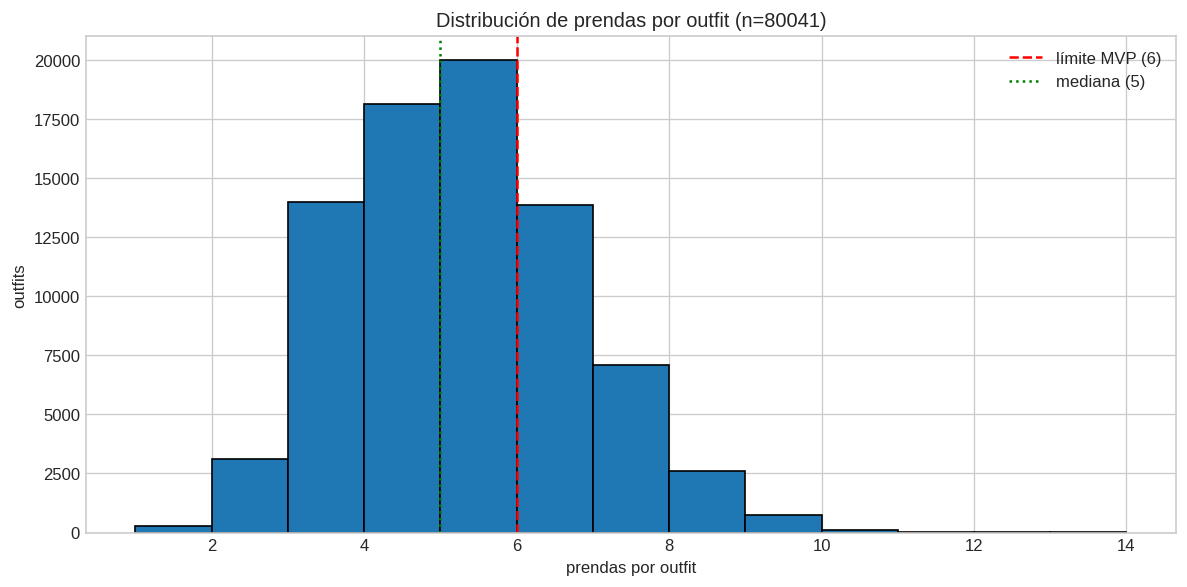

In [40]:
# Longitud de outfit y cobertura de catálogo (las resoluciones ya se midieron en el 01, sección 6)
import matplotlib.pyplot as plt
import numpy as np
import os
plt.style.use("seaborn-v0_8-whitegrid")

cnt_long = Counter(garments_per_outfit)
mediana = float(np.median(garments_per_outfit))
print(f"Distribución de prendas por outfit: {dict(sorted(cnt_long.items()))}")
print(f"Promedio: {np.mean(garments_per_outfit):.2f}, mediana: {mediana:.2f}")

con_catalogo = [sum(1 for g in o["garments"] if g["category"] != "sin_catalogo") for o in outfits]
total_prendas = sum(garments_per_outfit)
print(f"Prendas con categoría conocida: {sum(con_catalogo)}/{total_prendas} ({100*sum(con_catalogo)/total_prendas:.1f}%)")
completos = sum(1 for o in outfits if all(g["category"] != "sin_catalogo" for g in o["garments"]))
print(f"Outfits 100% catalogados: {completos}/{len(outfits)} ({100*completos/len(outfits):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.hist(garments_per_outfit, bins=range(1, max(garments_per_outfit)+2), edgecolor="black")
ax.axvline(6, color="red", linestyle="--", label="límite MVP (6)")
ax.axvline(mediana, color="green", linestyle=":", label=f"mediana ({mediana:.0f})")
ax.set_title(f"Distribución de prendas por outfit (n={len(outfits)})")
ax.set_xlabel("prendas por outfit")
ax.set_ylabel("outfits")
ax.legend()
fig.tight_layout()
fig.savefig("/tmp/fig_longitud.png", bbox_inches="tight")
plt.show()

## 2. Galería Visual de Outfits

Mostramos una selección de outfits del dataset con su estructura de prendas. Las imágenes reales no se descargan (son los 284 GB del dataset), así que la galería muestra información estructural.

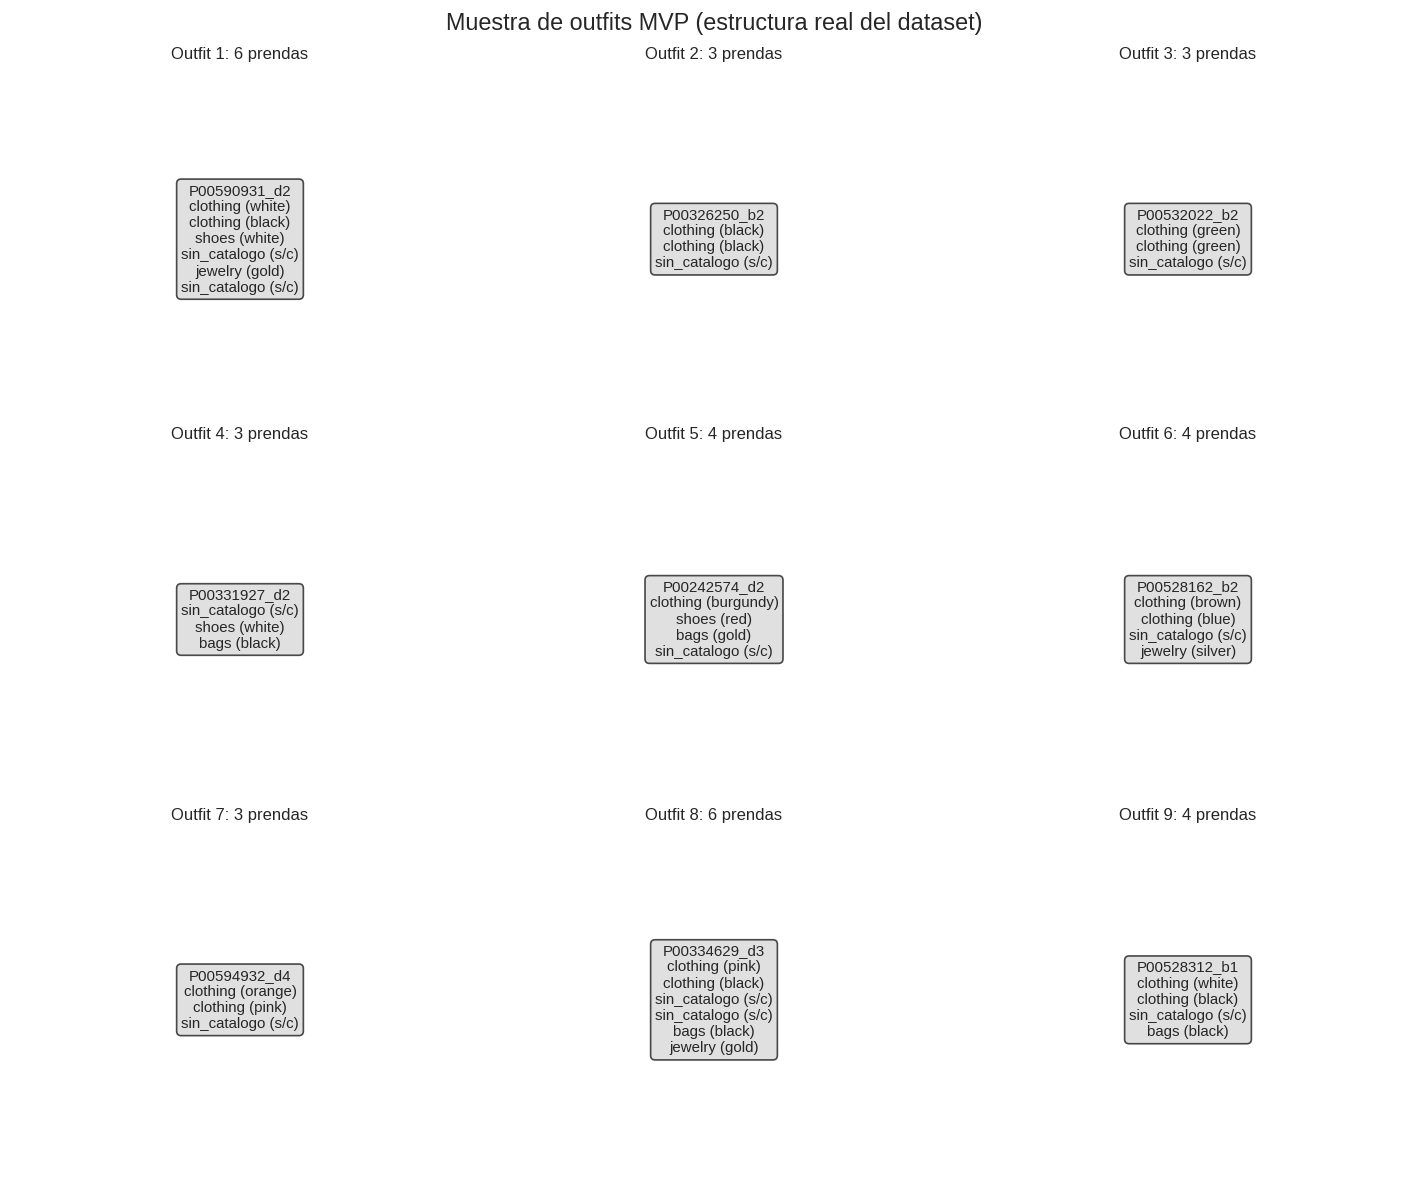

In [41]:
# Galería estructural 3x3 con categoría y color reales de cada prenda
gallery_count = min(9, len(outfits_mvp))
gallery_outfits = outfits_mvp[:gallery_count]

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(12, 10), dpi=120)
fig.suptitle('Muestra de outfits MVP (estructura real del dataset)', fontsize=14)

for i, outfit in enumerate(gallery_outfits):
    row, col = divmod(i, 3)
    ax = axes[row, col]

    prendas = outfit["garments"]
    lineas = [f"{g['category']} ({g['color'] or 's/c'})" for g in prendas]
    info_text = f"{outfit['outfit_id'][:14]}\n" + "\n".join(lineas)

    ax.text(0.5, 0.5, info_text, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
    ax.set_title(f"Outfit {i+1}: {len(prendas)} prendas", fontsize=10)
    ax.axis('off')

for i in range(gallery_count, 9):
    row, col = divmod(i, 3)
    axes[row, col].set_visible(False)

fig.tight_layout()
fig.savefig("/tmp/fig_galeria.png", bbox_inches="tight")
plt.show()

## 3. Distribución de categorías en profundidad

Análisis más detallado de las categorías de prendas, incluyendo subcategorías y su frecuencia.

Categorías principales (outfits MVP):
  clothing: 108945
  shoes: 57975
  sin_catalogo: 36547
  bags: 18970
  accessories: 15403
  jewelry: 13234
  bag: 11004
  top: 10028
  pants: 5223
  outwear: 5062
  dress: 4263
  eyewear: 3189
  skirt: 3171
  earrings: 2847
  necklace: 2125
  bracelet: 1997
  hats: 1280
  rings: 968
  watches: 837
  neckwear: 431
  brooch: 304
  hairwear: 234
  jumpsuit: 186
  gloves: 150
  legwear: 66
Top 15 subcategorías:
  sin_catalogo: 36547
  shoes: 11930
  bag: 11004
  fashion jewelry::earrings: 10196
  top: 10028
  tops::long-sleeved tops: 6436
  dresses::maxi dresses: 5687
  shoulder bags: 5632
  pants: 5223
  outwear: 5062
  pants::wide-leg pants: 4833
  top-handle bags: 4588
  pumps::mid-heel pumps: 4454
  knitwear::sweaters: 4313
  dress: 4263


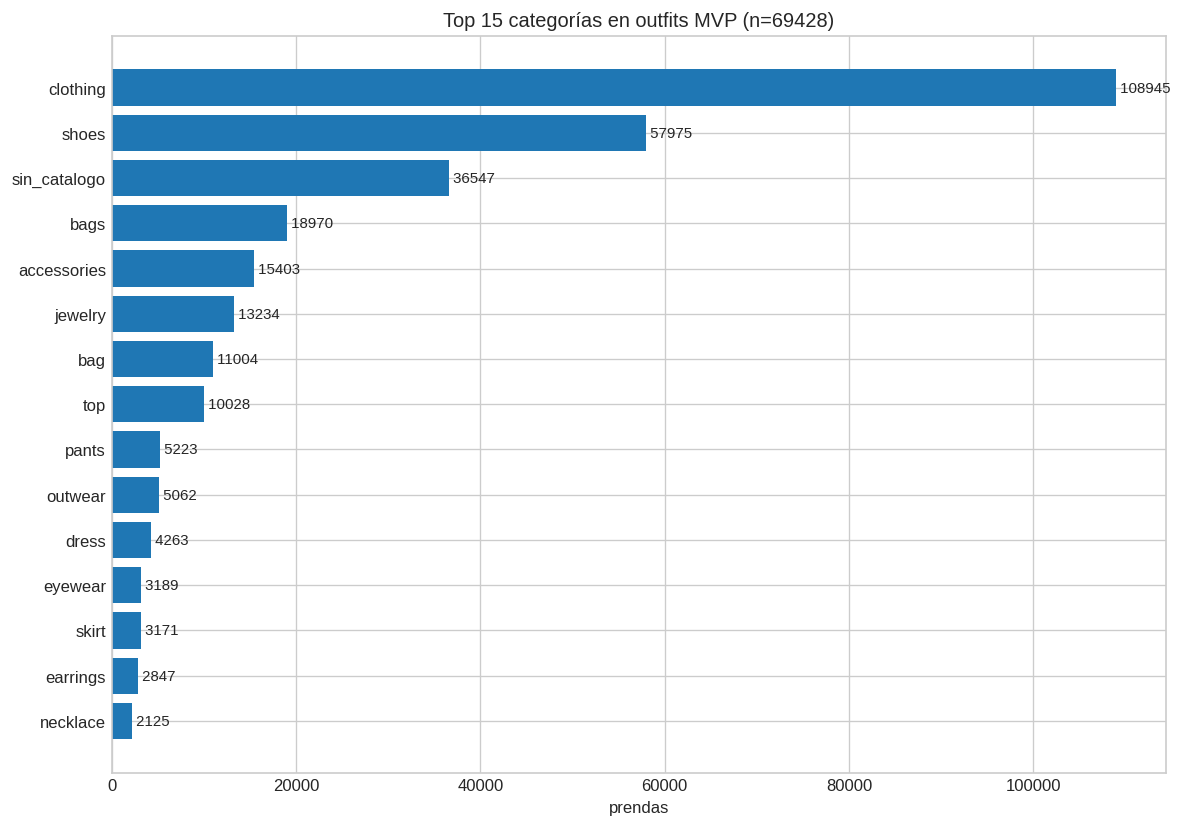

In [42]:
# Distribución de categorías sobre outfits MVP (imports locales: la celda corre sola)
from collections import Counter
import matplotlib.pyplot as plt

all_cats = []
all_subcats = []
for o in outfits_mvp:
    for g in o["garments"]:
        all_cats.append(g["category"])
        all_subcats.append(g["subcategory"])

cat_cnt = Counter(all_cats)
subcat_cnt = Counter(all_subcats)

print(f"Categorías principales (outfits MVP):")
for cat, count in cat_cnt.most_common():
    print(f"  {cat}: {count}")

print(f"Top 15 subcategorías:")
for subcat, count in subcat_cnt.most_common(15):
    print(f"  {subcat}: {count}")

top15 = cat_cnt.most_common(15)
fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh([c for c, _ in reversed(top15)], [v for _, v in reversed(top15)])
for i, v in enumerate([v for _, v in reversed(top15)]):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
ax.set_title(f"Top 15 categorías en outfits MVP (n={len(outfits_mvp)})")
ax.set_xlabel("prendas")
fig.tight_layout()
fig.savefig("/tmp/fig_categorias.png", bbox_inches="tight")
plt.show()

## 4. Estadísticas de composición por outfit

Resumen integral de cada outfit: número de prendas, categorías mezcladas, y otras propiedades del metadato.

In [43]:
# Estadísticas de composición sobre muestra de outfits MVP (categorías en inglés del catálogo)
from collections import Counter
from itertools import combinations
import numpy as np

outfit_stats = []
for o in outfits_mvp:
    garments = o["garments"]
    categories = [g["category"] for g in garments]
    stats = {
        'outfit_id': o["outfit_id"],
        'n_prendas': len(garments),
        'categorias': categories,
        'has_accessory': any(c in ("accessory", "accessories", "shoes") for c in categories),
        'has_outerwear': any(c in ("outerwear", "outwear") for c in categories),
    }
    outfit_stats.append(stats)

n = len(outfit_stats)
print(f"Resumen de {n} outfits MVP:")
print(f"  - Prendas promedio: {np.mean([s['n_prendas'] for s in outfit_stats]):.2f}")
acc = sum(1 for s in outfit_stats if s['has_accessory'])
out = sum(1 for s in outfit_stats if s['has_outerwear'])
print(f"  - Con accesorios o calzado: {acc} ({100*acc/n:.1f}%)")
print(f"  - Con outerwear: {out} ({100*out/n:.1f}%)")

# Combinaciones de categorías más comunes, sin sin_catalogo para señal limpia
cat_combos = []
for s in outfit_stats:
    cats = [c for c in set(s['categorias']) if c != "sin_catalogo"]
    if len(cats) >= 2:
        cat_combos.append(tuple(sorted(cats)))

combo_cnt = Counter(cat_combos)
print(f"Top 5 combinaciones de categorías:")
for combo, count in combo_cnt.most_common(5):
    print(f"  {combo}: {count}")

Resumen de 69428 outfits MVP:
  - Prendas promedio: 4.38
  - Con accesorios o calzado: 58496 (84.3%)
  - Con outerwear: 5035 (7.3%)
Top 5 combinaciones de categorías:
  ('clothing', 'shoes'): 16813
  ('bags', 'clothing', 'shoes'): 8547
  ('accessories', 'clothing', 'shoes'): 8439
  ('bags', 'clothing', 'jewelry', 'shoes'): 4571
  ('clothing', 'jewelry', 'shoes'): 4127


## 4b. Visualizaciones de composición

Las cuatro figuras que resumen el baseline: con quién se junta cada categoría, combinaciones top, cobertura en donas y curva acumulada del límite MVP.


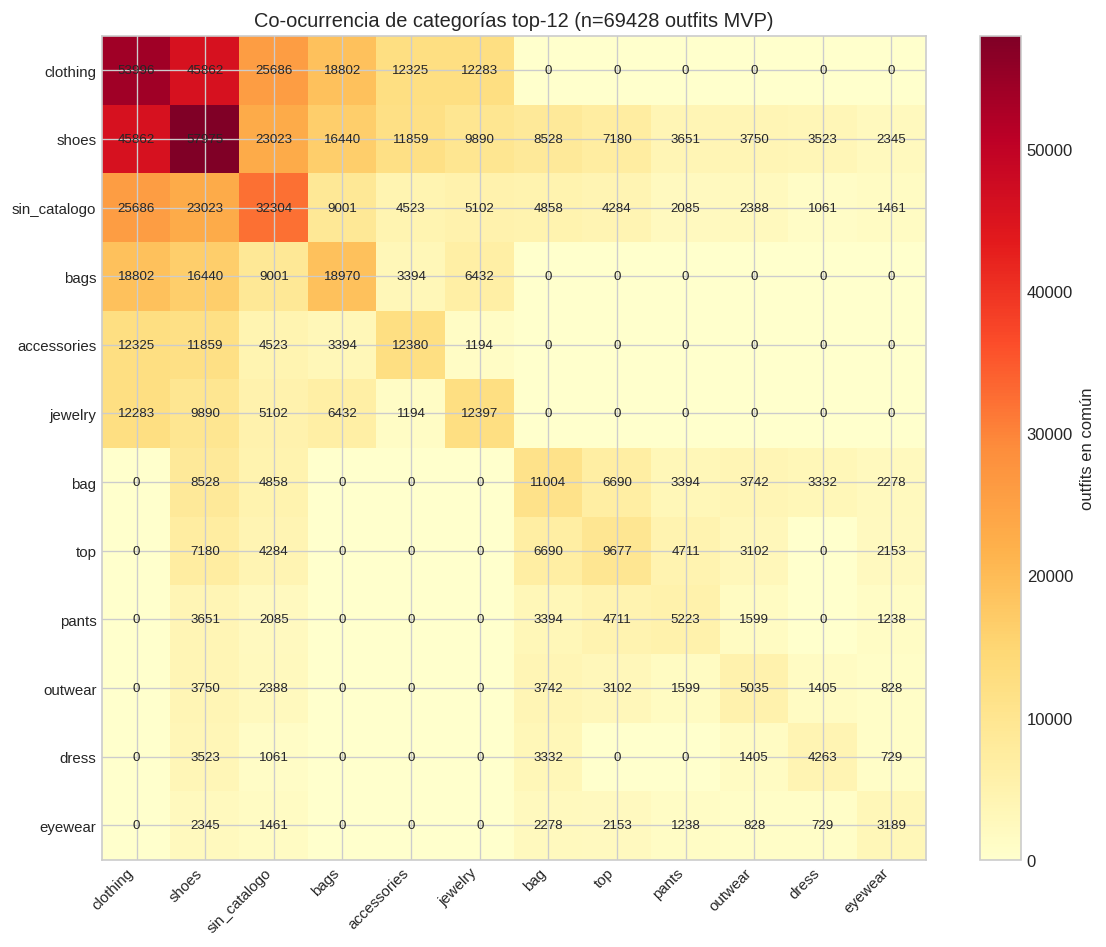

In [44]:
# Heatmap de co-ocurrencia top-12 categorías (la foto de qué se combina con qué)
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")

top_cats = [c for c, _ in cat_cnt.most_common(12)]
pos = {c: i for i, c in enumerate(top_cats)}
mat = np.zeros((len(top_cats), len(top_cats)), dtype=int)
for s in outfit_stats:
    presentes = [c for c in set(s["categorias"]) if c in pos]
    for a in presentes:
        for b in presentes:
            mat[pos[a], pos[b]] += 1

fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
im = ax.imshow(mat, cmap="YlOrRd")
ax.set_xticks(range(len(top_cats)), top_cats, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(top_cats)), top_cats, fontsize=9)
ax.set_title(f"Co-ocurrencia de categorías top-12 (n={len(outfit_stats)} outfits MVP)")
for i in range(len(top_cats)):
    for j in range(len(top_cats)):
        ax.text(j, i, mat[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="outfits en común")
fig.tight_layout()
fig.savefig("/tmp/fig_heatmap.png", bbox_inches="tight")
plt.show()


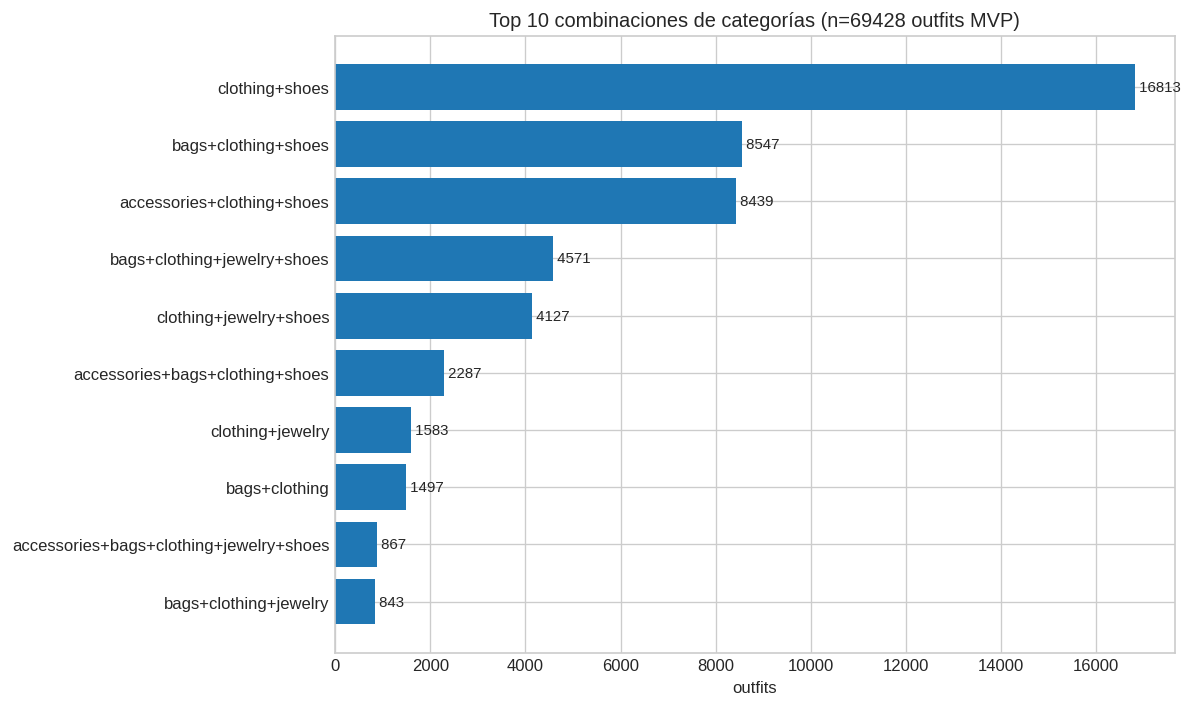

In [45]:
# Barras horizontales top-10 combinaciones
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

top10 = combo_cnt.most_common(10)
etiquetas = ["+".join(c) for c, _ in reversed(top10)]
valores = [v for _, v in reversed(top10)]
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.barh(etiquetas, valores)
for i, v in enumerate(valores):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
ax.set_title(f"Top 10 combinaciones de categorías (n={len(outfit_stats)} outfits MVP)")
ax.set_xlabel("outfits")
fig.tight_layout()
fig.savefig("/tmp/fig_combos.png", bbox_inches="tight")
plt.show()


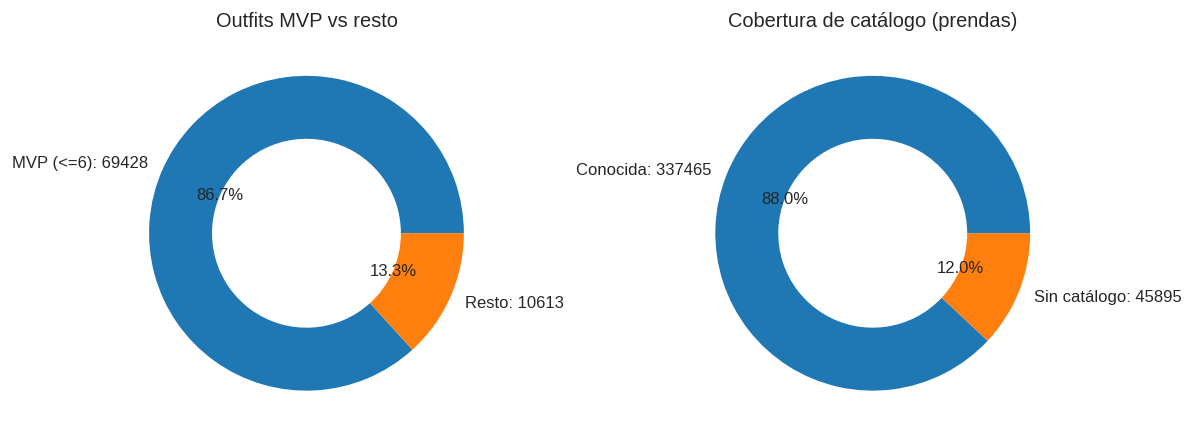

In [46]:
# Donas: outfits MVP vs resto + prendas con categoría conocida vs sin catálogo
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

mvp, resto = len(outfits_mvp), len(outfits) - len(outfits_mvp)
conocidas = sum(con_catalogo)
sin_cat = total_prendas - conocidas
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 5), dpi=120)
a1.pie([mvp, resto], labels=[f"MVP (<=6): {mvp}", f"Resto: {resto}"],
       autopct="%1.1f%%", wedgeprops=dict(width=0.4))
a1.set_title("Outfits MVP vs resto")
a2.pie([conocidas, sin_cat], labels=[f"Conocida: {conocidas}", f"Sin catálogo: {sin_cat}"],
       autopct="%1.1f%%", wedgeprops=dict(width=0.4))
a2.set_title("Cobertura de catálogo (prendas)")
fig.tight_layout()
fig.savefig("/tmp/fig_donas.png", bbox_inches="tight")
plt.show()


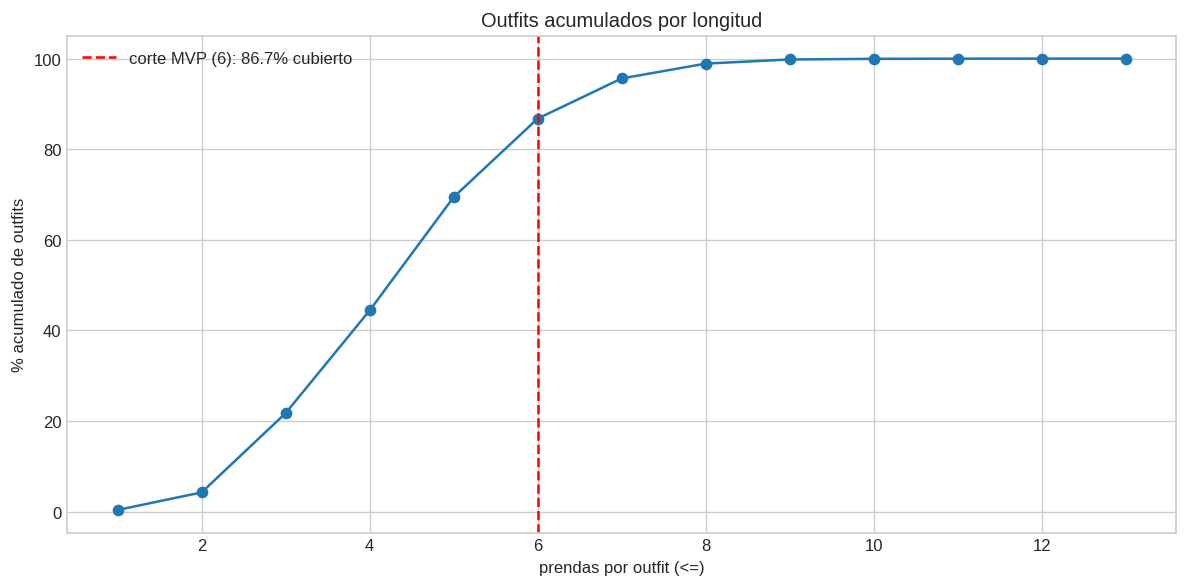

In [47]:
# Curva acumulada de longitud: justifica el corte MVP en 6
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")

xs = sorted(cnt_long)
acum = np.cumsum([cnt_long[x] for x in xs]) / len(outfits) * 100
pct6 = acum[xs.index(6)]
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(xs, acum, marker="o")
ax.axvline(6, color="red", linestyle="--", label=f"corte MVP (6): {pct6:.1f}% cubierto")
ax.set_title("Outfits acumulados por longitud")
ax.set_xlabel("prendas por outfit (<=)")
ax.set_ylabel("% acumulado de outfits")
ax.legend()
fig.tight_layout()
fig.savefig("/tmp/fig_acumulada.png", bbox_inches="tight")
plt.show()


## 5. Set de evaluación FITB (insumo del recomendador)

Se construye el set fill-in-the-blank: por cada outfit se esconde una prenda y se ofrecen 3 distractores de la misma categoría. Sirve para medir precisión de combinaciones (objetivo FITB mayor a 70%).

In [48]:
# Set FITB: esconder una prenda catalogada por outfit + 3 distractores de su categoría
import random
random.seed(42)

por_categoria = {}
for o in outfits_mvp:
    for g in o["garments"]:
        if g["category"] != "sin_catalogo":
            por_categoria.setdefault(g["category"], []).append(g["garment_id"])

fitb_set = []
for o in outfits_mvp[:500]:
    candidatas = [g for g in o["garments"] if g["category"] != "sin_catalogo"]
    if not candidatas:
        continue
    verdad = random.choice(candidatas)
    pozo = [gid for gid in por_categoria.get(verdad["category"], []) if gid != verdad["garment_id"]]
    if len(pozo) < 3:
        continue
    distractores = random.sample(pozo, 3)
    contexto = [g["garment_id"] for g in o["garments"] if g["garment_id"] != verdad["garment_id"]]
    fitb_set.append({"outfit_id": o["outfit_id"], "contexto": contexto,
                     "correcta": verdad["garment_id"], "opciones": distractores + [verdad["garment_id"]]})

assert len(fitb_set) > 0, "set FITB vacío"
assert all(len(c["opciones"]) == 4 and c["correcta"] in c["opciones"] for c in fitb_set)
print(f"Casos FITB: {len(fitb_set)} (de {min(500, len(outfits_mvp))} outfits MVP)")
print(f"Ejemplo: contexto={fitb_set[0]['contexto'][:3]} correcta={fitb_set[0]['correcta']}")

Casos FITB: 500 (de 500 outfits MVP)
Ejemplo: contexto=['P01021174', 'P00590931', 'UM00000002'] correcta=P00831132


**[INFO] Nota:** este notebook se queda en análisis estructural y set de evaluación. El DWPose denso vive en el notebook 03.

## 5b. Log composición a MLflow
Registra longitud, cobertura, top de combinaciones y tamaño del set FITB como métricas + artefactos.


In [49]:
import mlflow
import tempfile
import json
import os
from collections import Counter

with mlflow.start_run(run_name="composicion-outfits") as run:
    mlflow.log_param("notebook", "02_composicion_outfits")
    mlflow.log_metric("n_outfits", float(len(outfits)))
    mlflow.log_metric("n_outfits_mvp", float(len(outfits_mvp)))
    mlflow.log_metric("prom_prendas", float(prom))
    mlflow.log_metric("n_categorias", float(len(cat_cnt)))
    if cat_cnt:
        top_cat, top_cnt = cat_cnt.most_common(1)[0]
        mlflow.log_param("top_categoria", top_cat)
        mlflow.log_metric("top_categoria_count", float(top_cnt))
    if combo_cnt:
        top_combo, top_combo_cnt = combo_cnt.most_common(1)[0]
        mlflow.log_param("top_combinacion", "+".join(top_combo))
        mlflow.log_metric("top_combinacion_count", float(top_combo_cnt))
    mlflow.log_metric("n_casos_fitb", float(len(fitb_set)))
    mlflow.set_tag("phase", "composicion")
    with tempfile.TemporaryDirectory() as tmp:
        csv_path = f"{tmp}/categorias_counts.csv"
        with open(csv_path, "w") as f:
            f.write("categoria,count\n")
            for k,v in cat_cnt.most_common():
                f.write(f"{k},{v}\n")
        mlflow.log_artifact(csv_path, artifact_path="composicion")
        fitb_path = f"{tmp}/fitb_set.json"
        with open(fitb_path, "w") as f:
            json.dump(fitb_set, f)
        mlflow.log_artifact(fitb_path, artifact_path="composicion")
        for png in ["fig_longitud.png", "fig_galeria.png", "fig_categorias.png",
                    "fig_heatmap.png", "fig_combos.png", "fig_donas.png", "fig_acumulada.png"]:
            p = f"/tmp/{png}"
            if os.path.exists(p):
                mlflow.log_artifact(p, artifact_path="figs")
    print(f"[OK] MLflow run 02: {run.info.run_id}")


2026/09/23 21:04:36 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/09/23 21:04:36 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


[OK] MLflow run 02: 1f97080229d84fe7ab0de37d7449c9ad
🏃 View run composicion-outfits at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/1/runs/1f97080229d84fe7ab0de37d7449c9ad
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/1


2026/09/23 21:04:49 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/23 21:04:50 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


## 6. Veredicto del baseline de composición y cierre

Este notebook mide si las combinaciones tienen estructura, mientras el 01 mide si el probador genera bien. El set FITB queda construido y registrado en MLflow como artefacto, listo para evaluar precisión de combinaciones en el recomendador.

En deuda queda el DWPose denso, que vive en el notebook 03 junto al pipeline de visión.

La siguiente etapa es el pipeline de visión con MediaPipe, DWPose denso y máscaras agnósticas.
